---
# Imports

In [1]:
import os

print(os.listdir())

['main.ipynb', 'model_comparation.py', 'opadt.py', 'padt.py', 'plot.ipynb', 'results', 'time_series.py']


In [2]:
from Classes.time_series import (
    TimeSeries,
    TimeSeriesIO,
    TimeSeriesSplitter,
    RandomWalkUtilities,
)
from Classes.padt import (PADT)
from Classes.model_comparation import (SklearnWrapper, SciKerasWrapper, build_rnn_model, Trainer)

ModuleNotFoundError: No module named 'Classes'

---
# 1. Load Series

In [ ]:
ADEMIR_SERIES_PATH = "../data/raw/others"
M7_SERIES_PATH = "../data/clean/m7"

LOAD_SERIES_PATH = ADEMIR_SERIES_PATH

series = TimeSeriesIO.load_folder_csv(LOAD_SERIES_PATH)

Founded:
../data/raw/others\arma.csv
	-../data/raw/others\bitcoin.csv
	-../data/raw/others\co2_levels.csv
	-../data/raw/others\dolar.csv
	-../data/raw/others\dowjones.csv
	-../data/raw/others\global_temp.csv
	-../data/raw/others\gold.csv
	-../data/raw/others\ibovespa.csv
	-../data/raw/others\nile.csv
	-../data/raw/others\petrobras.csv
	-../data/raw/others\sea_level.csv
	-../data/raw/others\sp500.csv
	-../data/raw/others\sunspots.csv


---
## 1.1 Split

In [ ]:
TRAIN_PROPORTION = 0.6
VAL_PROPORTION = 0.2
TEST_PROPORTION = 1 - VAL_PROPORTION - TRAIN_PROPORTION

ts_splitter = TimeSeriesSplitter(splits={
    "train": TRAIN_PROPORTION,
    "val": VAL_PROPORTION,
    "test": TEST_PROPORTION
})

def split_series(series: list[TimeSeries]):
    for ts in series:
        ts.update_splits(ts_splitter)

split_series(list(series.values()))

---
# 1.2 Random Walk

In [ ]:
def extract_random_walk_series(series: list[TimeSeries]):
    rw_series = {}
    for ts in series:
        rw_series[ts.name] = RandomWalkUtilities.extract_random_walk(
            ts,
            split="original",
            target="y"
        )
        rw_series[ts.name].update_splits(ts_splitter)
    
    return rw_series

rw_series = extract_random_walk_series(list(series.values()))

---
# 2. Core

In [ ]:
# from sklearn.metrics import (
#     mean_absolute_error,
#     mean_absolute_percentage_error,
#     root_mean_squared_error
# )

# def theils_u(y_true, y_pred):
#     y_true = np.asarray(y_true)
#     y_pred = np.asarray(y_pred)

#     se_model = np.sum((y_true[1:] - y_pred[1:]) ** 2)
#     se_rw = np.sum((y_true[1:] - y_true[:-1]) ** 2)

#     return se_model / se_rw

Envolver

- XGBoost [*]
- LightGBM [*]
- Random Forest [*]
- LSTM [*]
- GRU [*]
- ETS
- AutoFormer
- MLP [*]
- ARIMA
- RIVER
- SVR-ONLINE

In [ ]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.svm import SVR
from sklearn.ensemble import RandomForestRegressor, BaggingRegressor
from sklearn.neural_network import MLPRegressor
import numpy as np
from lightgbm.sklearn import LGBMRegressor
from xgboost import XGBRegressor

Trainer.train(
    models=[
        SklearnWrapper(
            name="DTR",
            is_online=False,
            enabled=False,
            estimator=DecisionTreeRegressor(random_state=42),
            param_grid={
                "criterion": ["squared_error", "friedman_mse", "absolute_error"],
                
                "max_depth": [None, 2, 3, 4, 5, 6, 7],
                "min_samples_split": [2, 5, 10, 20],
                "min_samples_leaf": [1, 2, 5, 10],
                
                "max_features": [None, "sqrt", "log2"],
                
                "ccp_alpha": [0.0, 0.001, 0.01, 0.1]
            }
        ),
        SklearnWrapper(
            name="SVR",
            is_online=False,
            enabled=False,
            estimator=SVR(),
            param_grid={
                "kernel": ['linear', 'poly', 'rbf', 'sigmoid'],
                "C": [0.001, 0.01, 0.1, 1],
                "degree": [2, 3],
                "epsilon": [0.01, 0.1, 1]
            }
        ),
        SklearnWrapper(
            name="RF",
            is_online=False,
            enabled=False,
            estimator=RandomForestRegressor(random_state=42),
            param_grid={
                "n_estimators": [5, 10, 15, 20],
                "max_depth": list(range(2, 7)),
                "max_features": ["sqrt", "log2"]
            }
        ),
        SklearnWrapper(
            name="MLP",
            is_online=False,
            enabled=False,
            estimator=MLPRegressor(random_state=42),
            param_grid={
                "activation": ["relu", "identity", "logistic", "tanh"],
                "hidden_layer_sizes": [(20, 5), (10, 10), (50, 2)],
                "learning_rate": ["constant", "invscaling", "adaptive"],
                "learning_rate_init": [0.001, 0.01, 0.1]
            }
        ),
        SklearnWrapper(
            name="PADT-B",
            is_online=False,
            enabled=False,
            estimator=PADT(prediction_method="linear", decision_path_method="best"),
            param_grid={
                "characteristic_method": ["mean", "median"],
                "n_bins": list(range(2, 11)),
                "max_tree_depth": list(range(2, 7)),
                "alpha": np.linspace(0, 1, 10),
                "beta": np.linspace(0, 0.5, 5),
                "expectation_method": ["mid", "stm", "ltm", "midstm", "midltm"]
            }
        ),
        SklearnWrapper(
            name="PADT-A",
            is_online=False,
            enabled=False,
            estimator=PADT(decision_path_method="all"),
            param_grid={
                "prediction_method": ["exp", "linear", "sigmoid", "tanh"],
                "characteristic_method": ["mean", "median"],
                "n_bins": list(range(2, 11)),
                "max_tree_depth": list(range(2, 7)),
                "alpha": np.linspace(0, 1, 10),
                "beta": np.linspace(0, 0.5, 5),
                "expectation_method": ["mid", "stm", "ltm", "midstm", "midltm"]
            }
        ),
        SklearnWrapper(
            name="RF_PADT-B",
            is_online=False,
            enabled=False,
            estimator=BaggingRegressor(estimator=PADT(decision_path_method="best", prediction_method="linear"), random_state=42),
            param_grid={
                "estimator__characteristic_method": ["mean", "median"],
                "estimator__n_bins": list(range(2, 11)),
                "estimator__max_tree_depth": list(range(2, 7)),
                "estimator__alpha": np.linspace(0, 1, 10),
                "estimator__beta": np.linspace(0, 0.5, 5),
                "estimator__expectation_method": ["mid", "stm", "ltm", "midstm", "midltm"],
            }
        ),
        SklearnWrapper(
            name="RF_PADT-A",
            is_online=False,
            enabled=False,
            estimator=BaggingRegressor(estimator=PADT(decision_path_method="all"), random_state=42),
            param_grid={
                "estimator__prediction_method": ["linear", "exp", "sigmoid", "tanh"],
                "estimator__characteristic_method": ["mean", "median"],
                "estimator__n_bins": list(range(2, 11)),
                "estimator__max_tree_depth": list(range(2, 7)),
                "estimator__alpha": np.linspace(0, 1, 10),
                "estimator__beta": np.linspace(0, 0.5, 5),
                "estimator__expectation_method": ["mid", "stm", "ltm", "midstm", "midltm"],
            }
        ),
        SklearnWrapper(
            name="LGBM",
            is_online=False,
            enabled=False,
            estimator=LGBMRegressor(random_state=42),
            param_grid = {
                "num_leaves": [3, 5, 7, 15, 31, 63],
                "max_depth": [-1, 2, 3, 4, 5, 6, 7],
                "learning_rate": [0.01, 0.05, 0.1],
                "n_estimators": [10, 50, 100, 200],
                "min_child_samples": [10, 20, 40],
                "subsample": [0.7, 0.9],
                "colsample_bytree": [0.7, 0.9],
                "reg_alpha": [0.0, 0.1],
                "reg_lambda": [0.0, 1.0]
            }
        ),
        SklearnWrapper(
            name="XGBR",
            is_online=False,
            enabled=False,
            estimator=XGBRegressor(random_state=42),
            param_grid={
                "max_depth": [2, 3, 5, 7, 10],
                "min_child_weight": [1, 3, 5],
                "gamma": [0, 0.1, 0.5],
                "subsample": [0.7, 0.9],
                "colsample_bytree": [0.7, 0.9],
                "reg_alpha": [0, 0.1],
                "reg_lambda": [1, 5],
                "learning_rate": [0.01, 0.05, 0.1],
                "n_estimators": [10, 50, 100]
            }
        ),
        SciKerasWrapper(
            name="LSTM",
            is_online=False,
            enabled=False,
            model_builder=build_rnn_model,
            param_grid={
                "model__cell_type": ["lstm"],
                "model__units": [32, 64],
                "model__dropout": [0.1, 0.3],
                "model__lr": [0.001, 0.0001],
                "batch_size": [16, 32, 48],
                "epochs": [20, 30, 40, 50, 60, 70, 80, 90, 100],
            }
        ),
        SciKerasWrapper(
            name="GRU",
            is_online=False,
            enabled=False,
            model_builder=build_rnn_model,
            param_grid={
                "model__cell_type": ["gru"],
                "model__units": [32, 64],
                "model__dropout": [0.1, 0.3],
                "model__lr": [0.001],
                "batch_size": [16, 32, 48],
                "epochs": [20, 30, 40, 50, 60, 70, 80, 90, 100],
            }
        )
    ],
    rw_series={
        "co2_levels": rw_series["co2_levels"],
        "nile": rw_series["nile"]
    },
    target_series={
        "co2_levels": series["co2_levels"],
        "nile": series["nile"]
    },
    train_size=0.6,
    output_dir="results"
)

[LOG] Starting training pipeline...
[LOG] Series: co2_levels
	[LOG] Skipping FPADT-B...
	[LOG] Skipping DTR...
	[LOG] Skipping SVR...
	[LOG] Skipping RF...
	[LOG] Skipping MLP...
	[LOG] Skipping PADT-B...
	[LOG] Skipping PADT-A...
	[LOG] Skipping RF_PADT-B...
	[LOG] Skipping RF_PADT-A...
	[LOG] Skipping LGBM...
	[LOG] Skipping XGBR...
	[LOG] Skipping LSTM...
	[LOG] Skipping GRU...
[LOG] Series: nile
	[LOG] Skipping FPADT-B...
	[LOG] Skipping DTR...
	[LOG] Skipping SVR...
	[LOG] Skipping RF...
	[LOG] Skipping MLP...
	[LOG] Skipping PADT-B...
	[LOG] Skipping PADT-A...
	[LOG] Skipping RF_PADT-B...
	[LOG] Skipping RF_PADT-A...
	[LOG] Skipping LGBM...
	[LOG] Skipping XGBR...
	[LOG] Skipping LSTM...
	[LOG] Skipping GRU...
[LOG] Saving results...
[LOG] Results saved in 'results'


In [ ]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


def load_all_results(results_dir: str) -> pd.DataFrame:
    dfs = []

    for file in os.listdir(results_dir):
        if file.endswith(".csv"):
            path = os.path.join(results_dir, file)
            df = pd.read_csv(path)
            dfs.append(df)

    if not dfs:
        raise ValueError("No CSV files found.")

    return pd.concat(dfs, ignore_index=True)

def filter_phase(df: pd.DataFrame, phase: str) -> pd.DataFrame:
    return df[df["Phase"] == phase].copy()

def compute_metrics(df: pd.DataFrame) -> pd.DataFrame:
    grouped = df.groupby(["series_name", "model"])

    metrics = grouped.agg({
        "AE": "mean",
        "SE": "mean",
        "APE": "mean"
    }).reset_index()

    return metrics

def rank_per_series(metrics_df: pd.DataFrame) -> pd.DataFrame:
    df = metrics_df.copy()

    for metric in ["AE", "SE", "APE"]:
        df[f"rank_{metric}"] = (
            df.groupby("series_name")[metric]
              .rank(method="min", ascending=True)
        )

    return df

def rank_global(metrics_df: pd.DataFrame) -> pd.DataFrame:
    grouped = (
        metrics_df
        .groupby("model")
        .mean(numeric_only=True)
        .reset_index()
    )

    for metric in ["AE", "SE", "APE"]:
        grouped[f"rank_{metric}"] = grouped[metric].rank(
            method="min", ascending=True
        )

    return grouped.sort_values("rank_AE")



def plot_rank_distribution(rank_df: pd.DataFrame, metric: str):
    plt.figure()

    for model in rank_df["model"].unique():
        vals = rank_df[rank_df["model"] == model][f"rank_{metric}"]
        plt.hist(vals, alpha=0.5, label=model)

    plt.legend()
    plt.title(f"Rank Distribution ({metric})")
    plt.show()


def _find_phase_boundary(df: pd.DataFrame, series_name: str):
    sub = df[df["series_name"] == series_name].sort_values("index")

    phases = sub[["index", "Phase"]].drop_duplicates()

    prev = phases.iloc[0]["Phase"]

    for _, row in phases.iterrows():
        if row["Phase"] != prev:
            return row["index"]
        prev = row["Phase"]

    return None

def _get_colors(n: int):
    cmap = plt.cm.get_cmap("tab20", n)
    return [cmap(i) for i in range(n)]

def plot_predictions(df: pd.DataFrame, series_name: str):
    subset = df[df["series_name"] == series_name].copy()
    subset = subset.sort_values("index")

    models = subset["model"].unique()
    colors = _get_colors(len(models))

    plt.figure(figsize=(14, 6))

    target = subset.groupby("index")["target"].first()

    plt.plot(
        target.index,
        target.values,
        color="black",
        linewidth=2.5,
        label="target",
        zorder=5
    )

    for model, color in zip(models, colors):
        mdf = subset[subset["model"] == model]

        plt.plot(
            mdf["index"],
            mdf["pred"],
            color=color,
            linewidth=1.5,
            label=model
        )

    split_x = _find_phase_boundary(df, series_name)

    if split_x is not None:
        plt.axvline(
            x=split_x,
            color="red",
            linestyle="--",
            linewidth=2,
            label="phase split"
        )

    plt.title(f"Series: {series_name}", fontsize=14)
    plt.xlabel("Index")
    plt.ylabel("Value")

    plt.grid(alpha=0.2)

    plt.legend(
        bbox_to_anchor=(1.02, 1),
        loc="upper left",
        borderaxespad=0
    )

    plt.tight_layout()
    plt.show()

def evaluate_models(results_dir: str, phase: str = "val"):
    df = load_all_results(results_dir)

    if phase is not None:
        df = filter_phase(df, phase)

    metrics = compute_metrics(df)
    rank_series = rank_per_series(metrics)
    rank_global_df = rank_global(metrics)

    return {
        "raw": df,
        "metrics": metrics,
        "rank_per_series": rank_series,
        "rank_global": rank_global_df
    }

def plot_ae_boxplot_per_series(df: pd.DataFrame, series_name: str, phase: str):
    subset = df[
        (df["series_name"] == series_name) &
        (df["Phase"] == phase)
    ].copy()

    if subset.empty:
        print(f"No data for {series_name} in phase {phase}")
        return

    order = (
        subset
        .groupby("model")["AE"]
        .median()
        .sort_values()
        .index
    )

    plt.figure(figsize=(14, 6))

    data = [subset[subset["model"] == m]["AE"].values for m in order]

    plt.boxplot(data, tick_labels=order, showfliers=True)

    plt.title(f"AE Distribution - {series_name} ({phase})")
    plt.xlabel("Model")
    plt.ylabel("Absolute Error (AE)")
    plt.xticks(rotation=45)

    plt.grid(alpha=0.2)
    plt.tight_layout()
    plt.show()

def plot_ae_boxplot_all_series(df: pd.DataFrame, phase: str):
    series_list = df["series_name"].unique()

    for series_name in series_list:
        plot_ae_boxplot_per_series(df, series_name, phase)

In [ ]:
results = evaluate_models("results", phase="val")

rank_series = results["rank_per_series"]
_rank_global = results["rank_global"]

print(_rank_global)

        model         AE            SE       APE  rank_AE  rank_SE  rank_APE
5      PADT-A  67.293530  14411.174956  0.086171      1.0      1.0       1.0
8   RF_PADT-B  70.034638  15724.852586  0.088382      2.0      2.0       3.0
10       XGBR  70.158852  16988.729576  0.088363      3.0      7.0       2.0
2        LGBM  70.611725  15990.443746  0.088981      4.0      4.0       5.0
7          RF  70.769456  15975.778348  0.088588      5.0      3.0       4.0
0         DTR  72.816327  15997.471465  0.092548      6.0      5.0       7.0
6      PADT-B  72.840877  16506.792968  0.093364      7.0      6.0       8.0
9         SVR  74.212001  17579.956075  0.092259      8.0      8.0       6.0
4         MLP  74.797834  18007.562654  0.094036      9.0      9.0       9.0
3        LSTM  75.362582  18172.828279  0.094539     10.0     10.0      10.0
1         GRU  75.783344  18354.040800  0.095024     11.0     11.0      11.0


In [ ]:
rank_series

,series_name,model,AE,SE,APE,rank_AE,rank_SE,rank_APE
0,co2_levels,DTR,0.234375,0.090922,0.000664,11.0,11.0,11.0
1,co2_levels,GRU,0.223041,0.082647,0.000631,10.0,10.0,10.0
2,co2_levels,LGBM,0.219067,0.079179,0.000620,8.0,6.0,8.0
3,co2_levels,LSTM,0.215622,0.078142,0.000610,4.0,5.0,4.0
4,co2_levels,MLP,0.218634,0.079676,0.000619,7.0,8.0,7.0
5,co2_levels,PADT-A,0.218537,0.079537,0.000619,6.0,7.0,6.0
6,co2_levels,PADT-B,0.219521,0.080508,0.000622,9.0,9.0,9.0
7,co2_levels,RF,0.213317,0.076611,0.000604,1.0,1.0,1.0
8,co2_levels,RF_PADT-B,0.217510,0.077874,0.000616,5.0,4.0,5.0
9,co2_levels,SVR,0.214522,0.076634,0.000607,2.0,2.0,2.0


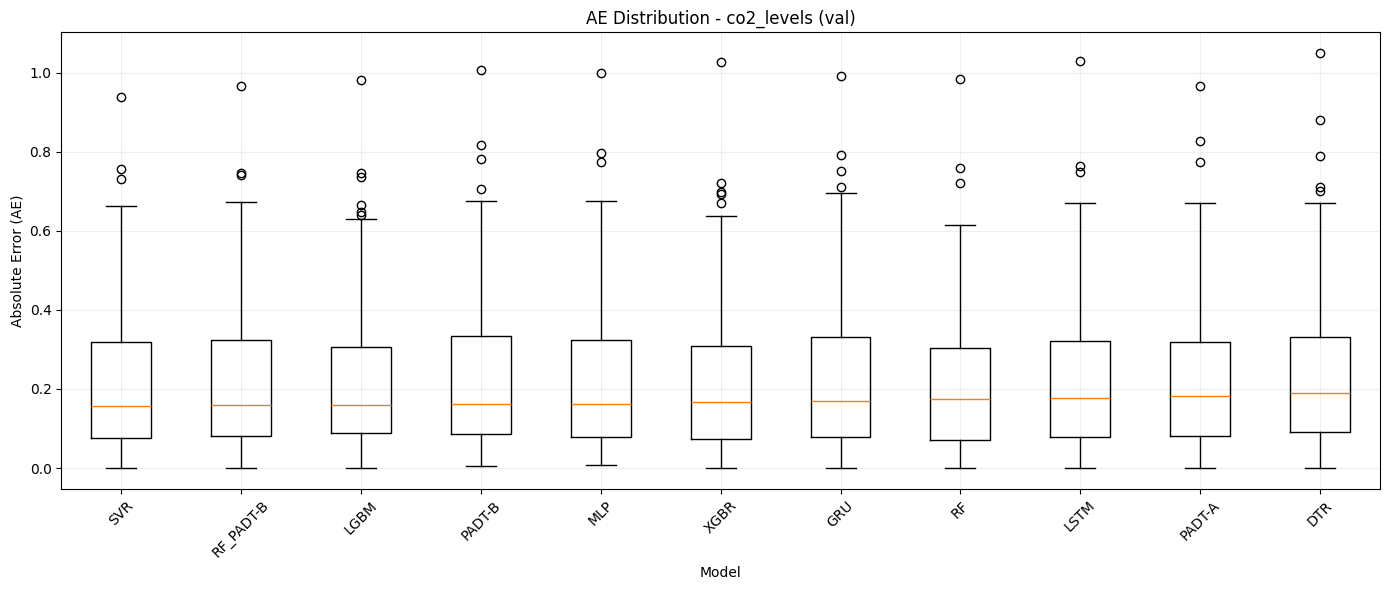

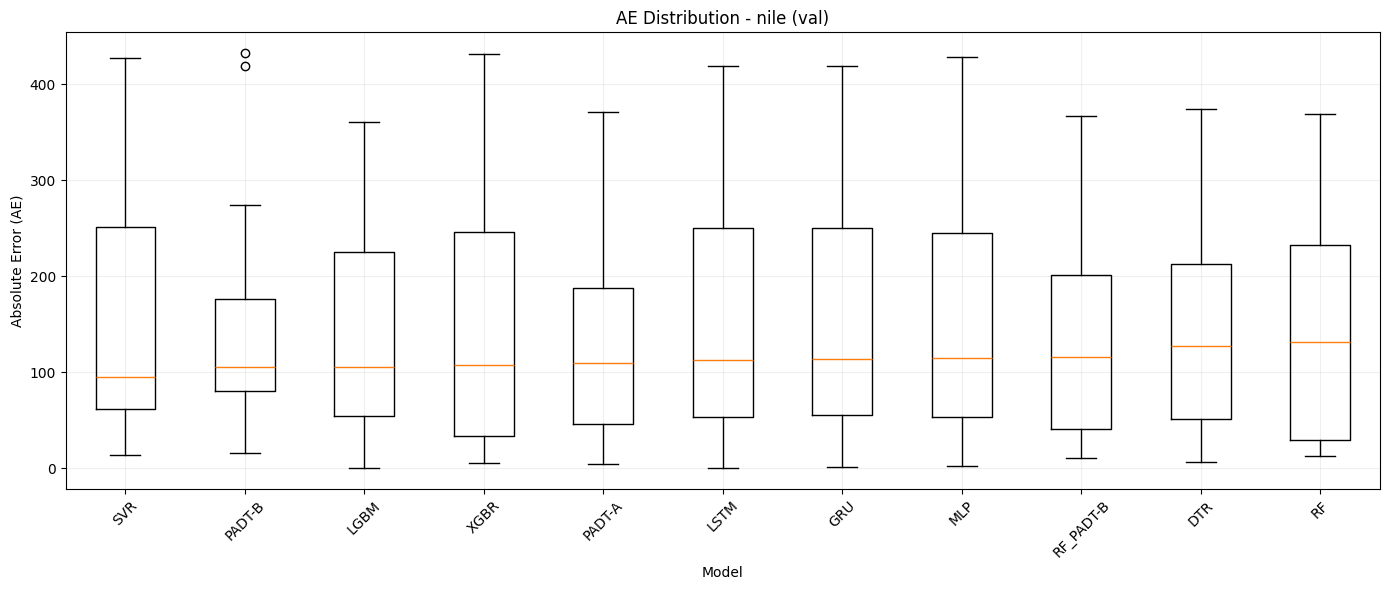

In [ ]:
results = evaluate_models("results", phase="val")

df = results["raw"]

plot_ae_boxplot_all_series(df, "val")